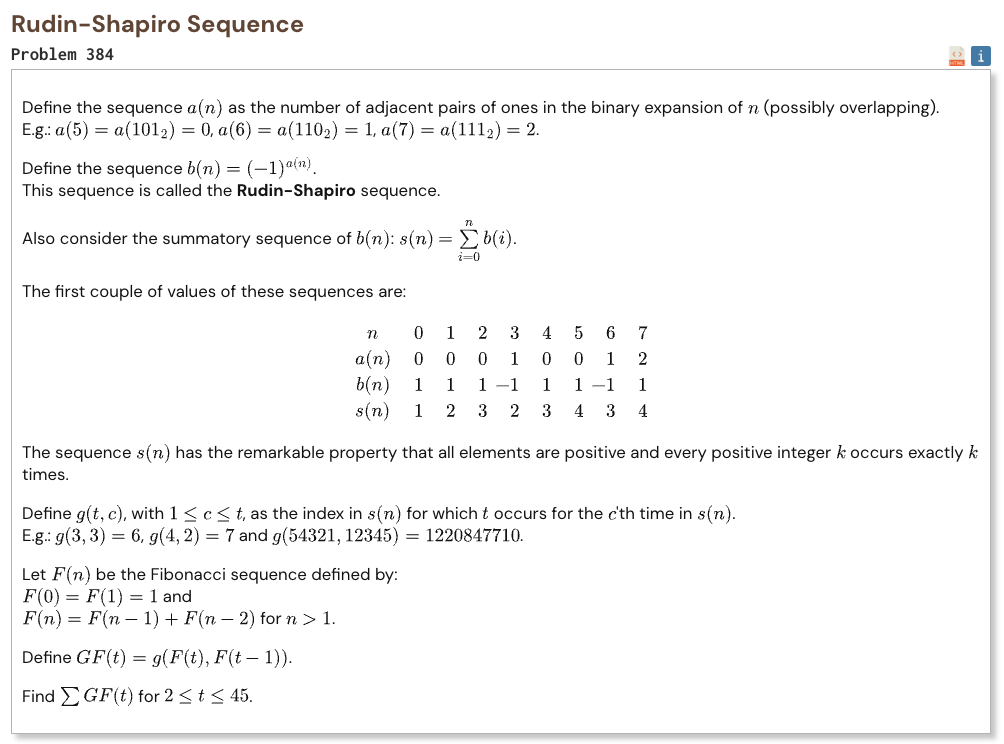

## Initial approach

* use the self-similar binary structure of the Rudin-Shapiro sequence
* define a recursive function for the index where value t appears for the cth time
* split t using the largest power of two not greater than t
* map each occurrence into a smaller equivalent occurrence
* add the correct block offset while moving through the sequence
* generate the Fibonacci numbers from F0 to F45
* calculate g of Ft and F t minus 1 for every t from 2 to 45
* add all these indices to get the final result

In [1]:
def g(t, c):
    if t == 1:
        return 0

    h = 1 << (t.bit_length() - 1)
    d = t - h

    if d == 0:
        if c <= t // 2:
            return t * t // 4 + g(t // 2, c)

        return t * t // 2 + g(t, c - t // 2)

    if c > h:
        return h * h + g(2 * h - d, c - h)

    if c > h - d:
        return h * h + g(d, c + d - h)

    if c <= d:
        return h * h // 2 + g(d, c)

    return h * h // 2 + g(2 * h - t, c)

In [2]:
%%time
fibonacci = [1, 1]

for _ in range(2, 46):
    fibonacci.append(fibonacci[-1] + fibonacci[-2])

result = 0

for t in range(2, 46):
    result += g(fibonacci[t], fibonacci[t - 1])

print("Result:", result)

Result: 3354706415856332783
CPU times: user 383 μs, sys: 87 μs, total: 470 μs
Wall time: 412 μs
